# Tutorial 12: Basic AutoEncoders

### 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Load and Normalize Data

In [2]:
# Image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### 3. Define the Autoencoder Model

In [3]:
# 1. Basic Autoencoder
class BasicAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2), # 14x14
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 7x7 (Latent Space)
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2), nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2), nn.Conv2d(16, 1, 3, padding=1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# 2. Improved Autoencoder (Task: Deeper layers + ConvTranspose)
class ImprovedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.LeakyReLU(0.2), # 14x14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.LeakyReLU(0.2) # 7x7
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

basic_model = BasicAutoencoder().to(device)
improved_model = ImprovedAutoencoder().to(device)

### 4. Train both the Autoencoder Models

In [4]:
def train(model, loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    loss_list = []

    model.train()
    for epoch in range(epochs):
        batch_loss = 0
        for images, _ in loader:
            images = images.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            batch_loss += loss.item()

        avg_loss = batch_loss / len(loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")
    return loss_list

print("Training Basic Model...")
basic_model_loss = train(basic_model, train_loader)

print("\nTraining Improved Model...")
improved_model_loss = train(improved_model, train_loader)

Training Basic Model...
Epoch 1 Loss: 0.0472
Epoch 2 Loss: 0.0090
Epoch 3 Loss: 0.0073
Epoch 4 Loss: 0.0065
Epoch 5 Loss: 0.0060

Training Improved Model...
Epoch 1 Loss: 0.0126
Epoch 2 Loss: 0.0008
Epoch 3 Loss: 0.0006
Epoch 4 Loss: 0.0005
Epoch 5 Loss: 0.0004


### 5. Plotting the Losses

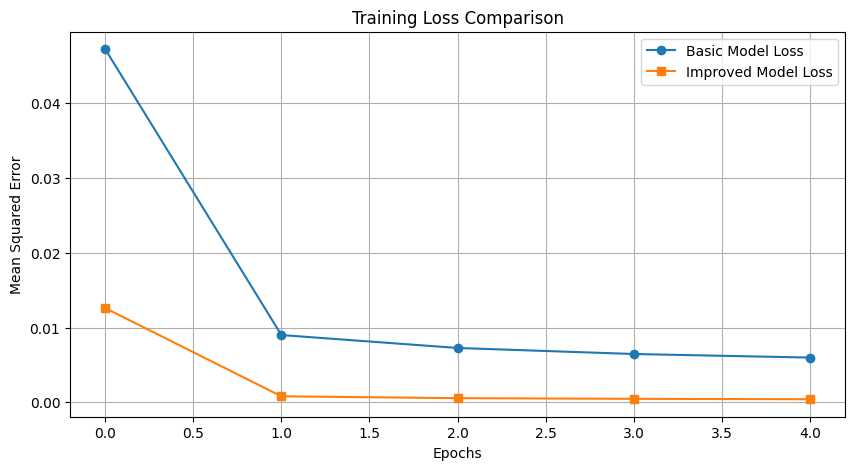

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(basic_model_loss, label='Basic Model Loss', marker='o')
plt.plot(improved_model_loss, label='Improved Model Loss', marker='s')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

### 6. Visualize the Results

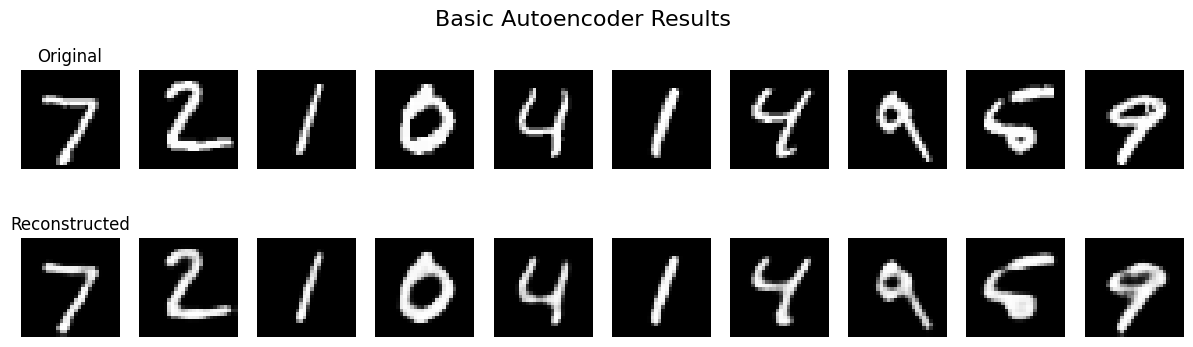

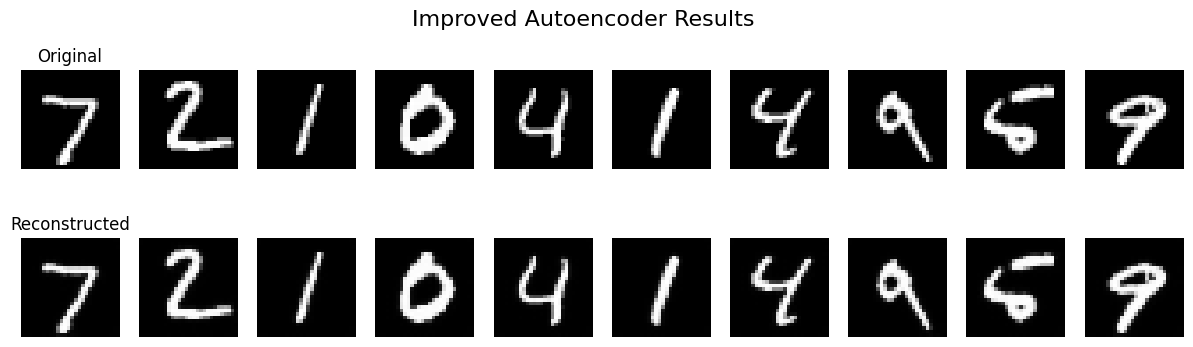

In [6]:
def visualize_results(model, title):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(test_loader))
        images = images.to(device)
        outputs = model(images).cpu()
        images = images.cpu()

    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16)
    for i in range(10):
        # Original
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Original")

        # Reconstructed
        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Reconstructed")
    plt.show()

visualize_results(basic_model, "Basic Autoencoder Results")
visualize_results(improved_model, "Improved Autoencoder Results")